# Baseline 5 (Proposed): MS-ProtoNet-50 — Multi-Scale ResNet50 + ProtoNet

## Novelty
Same multi-scale recipe as Baseline 4, but using a **ResNet50** trunk.

- `layer2` —  512 channels  →  Linear(512 → 128)
- `layer3` — 1024 channels  →  Linear(1024 → 128)
- `layer4` — 2048 channels  →  Linear(2048 → 128)

Final embedding: concat → **384-D**.

**Hypothesis:** the deeper trunk should give richer mid-level features at layer2/layer3, amplifying the benefit of multi-scale fusion compared to Baseline 4.


## 1. Imports & shared methodology

Everything except the encoder lives in `fewshot_lib.py` so all 5 baselines use the **identical training & evaluation pipeline**.


In [1]:
import torch
import torch.nn as nn
from torchvision import models

from fewshot_lib import (
    run_few_shot,
    summarize_results,
    plot_confusion_matrices,
    plot_training_curves,
    plot_training_loss_and_accuracy,
    evaluate_from_checkpoint,
    diagnose_checkpoint,
    predict_image,
)


## 2. Encoder definition (the only baseline-specific piece)


In [2]:
class ResNet50MultiScale(nn.Module):
    """Multi-scale ResNet50 → 384-D embedding (concat of three 128-D scales).

    `freeze_until`: 'none' | 'layer3' | 'layer4' | 'all'.
    """

    def __init__(self, freeze_until: str = "layer3"):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool
        self.layer1  = base.layer1
        self.layer2  = base.layer2  #  512 ch
        self.layer3  = base.layer3  # 1024 ch
        self.layer4  = base.layer4  # 2048 ch

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(1024, 128)
        self.fc4 = nn.Linear(2048, 128)

        self._apply_freeze(freeze_until)

    def _apply_freeze(self, mode: str):
        trunk = [self.conv1, self.bn1, self.layer1, self.layer2,
                 self.layer3, self.layer4]
        if mode == "none":
            return
        for m in trunk:
            for p in m.parameters():
                p.requires_grad = False
        if mode == "all":
            return
        unfreeze = {"layer3": [self.layer3, self.layer4],
                    "layer4": [self.layer4]}[mode]
        for m in unfreeze:
            for p in m.parameters():
                p.requires_grad = True

    def forward(self, x):
        x = self.conv1(x); x = self.bn1(x); x = self.relu(x); x = self.maxpool(x)
        x  = self.layer1(x)
        f2 = self.layer2(x)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)

        v2 = self.gap(f2).view(f2.size(0), -1)
        v3 = self.gap(f3).view(f3.size(0), -1)
        v4 = self.gap(f4).view(f4.size(0), -1)

        z2 = self.fc2(v2)
        z3 = self.fc3(v3)
        z4 = self.fc4(v4)

        return torch.cat([z2, z3, z4], dim=1)


## 3. Train + evaluate (1-shot, 5-shot, 10-shot)

Hyperparameters used for every baseline so cross-baseline comparisons are fair:

| Param | Value | Note |
|---|---:|---|
| `n_train_episodes` | 400 | Every baseline runs all 400 episodes for comparable curves. |
| `early_stop` | False | We run all episodes and **only use the best-val checkpoint** for evaluation. |
| `val_every` | 20 | Validation accuracy checked every 20 training episodes. |
| `n_eval_episodes` | 200 | Episodic test evaluation. |
| `n_test_seeds` | 30 | Deterministic full-test evaluation. |
| `n_query` | 10 | Some val classes only have 8 images; 10 is the safe upper bound. |
| `learning_rate` | 1e-4 | Was 1e-3 originally — that's what made loss collapse to 0. |
| `weight_decay` | 1e-4 | Mild L2. |
| Augmentation | RandomResizedCrop + Flip + ColorJitter + Rotation | Training only; eval is deterministic. |
| Backbone freezing | per encoder default | See the encoder docstring. |

The best-val checkpoint per shot count is automatically saved to `checkpoints/`.


In [3]:
results = run_few_shot(
    encoder_factory=lambda: ResNet50MultiScale(freeze_until='layer3'),
    baseline_name='Baseline 5 (Proposed)',
    data_root='clean_dataset',
    n_support_list=[1, 5, 10],
    n_way=4,
    n_query=10,
    n_train_episodes=400,
    val_every=20,
    early_stop=False,    # run all 400 episodes for comparable curves
    n_eval_episodes=200,
    n_test_seeds=30,
    learning_rate=1e-4,
    weight_decay=1e-4,
    seed=42,
    save_dir='checkpoints',
)


Using device: mps
  Test-Time Augmentation (TTA): ENABLED  (10 perturbations per test image)
[Baseline 5 (Proposed)] Classes: ['-K', '-N', '-P', 'FN']
  train: {'-K': 150, '-N': 135, '-P': 162, 'FN': 105}
  val: {'-K': 14, '-N': 8, '-P': 8, 'FN': 23}
  test: {'-K': 4, '-N': 4, '-P': 4, 'FN': 14}

  [Baseline 5 (Proposed)] 1-shot learning
  Trainable params: 22,522,240
  ep   20/400  loss=0.5638  train_acc=0.8250  val_acc=0.8295  ← new best  → saved checkpoints/Baseline_5_(Proposed)_1shot.pt
  ep   40/400  loss=0.1359  train_acc=1.0000  val_acc=0.9315  ← new best  → saved checkpoints/Baseline_5_(Proposed)_1shot.pt
  ep   60/400  loss=0.0052  train_acc=1.0000  val_acc=0.8635  (no-improve 1/5)
  ep   80/400  loss=0.0010  train_acc=1.0000  val_acc=0.8990  (no-improve 2/5)
  ep  100/400  loss=0.0004  train_acc=1.0000  val_acc=0.9205  (no-improve 3/5)
  ep  120/400  loss=0.0003  train_acc=1.0000  val_acc=0.9115  (no-improve 4/5)
  ep  140/400  loss=0.0005  train_acc=1.0000  val_acc=0.9065  (

## 4. Results summary (overall + per-class)


In [4]:
summarize_results(results, baseline_name='Baseline 5 (Proposed)')


  Baseline 5 (Proposed) — overall
   Shot Accuracy Precision (M) Recall (M) F1 (M)    Episodic μ±σ  95% CI       Best val   Full-test μ±σ
 1-shot   0.8598        0.8663     0.8598 0.8571 0.8597 ± 0.0758 ±0.0105  0.9315 @ ep40 0.7736 ± 0.0299
 5-shot   0.9520        0.9597     0.9520 0.9516 0.9520 ± 0.0422 ±0.0058 0.9785 @ ep400 0.8545 ± 0.0192
10-shot   0.9337        0.9476     0.9337 0.9326 0.9337 ± 0.0591 ±0.0082  0.9580 @ ep40 0.7986 ± 0.0143

Per-class metrics on TEST split (deterministic full-test eval):

   Shot Class Precision Recall     F1
 1-shot    -K    0.9714 0.7933 0.8734
 1-shot    -N    0.4269 0.9717 0.5932
 1-shot    -P    0.8782 0.9858 0.9289
 1-shot    FN    0.9967 0.6507 0.7874
 5-shot    -K    0.9230 0.9983 0.9592
 5-shot    -N    0.5216 0.8358 0.6423
 5-shot    -P    1.0000 0.9867 0.9933
 5-shot    FN    0.9661 0.7810 0.8637
10-shot    -K    0.8697 0.9292 0.8985
10-shot    -N    0.4478 0.9083 0.5999
10-shot    -P    0.9680 0.9583 0.9631
10-shot    FN    0.9924 0.68

## 5. Training loss & training accuracy

How to read this plot:

- **Blue (left axis, log-scaled)** — training loss per episode (raw + smoothed average).
  - Healthy: loss decreases gradually, plateaus around 1e-2 to 1e-1.
  - Loss → 0 means the encoder has memorised the training set. **This is OK as long as the val accuracy is also high** — and the red dashed line marks where we stopped using the model for evaluation.
- **Green (right axis)** — training accuracy on the query of each training episode (smoothed).
- **Orange markers (right axis)** — validation accuracy at each `val_every` checkpoint.
- **Red dashed line** — the episode where we got the BEST validation accuracy. The model state at that episode is what was saved to `checkpoints/` and what produced the test results above.

If train_acc → 1.00 while val_acc plateaus or drops, that's textbook overfitting — and the early-stopping checkpoint protects you from it.


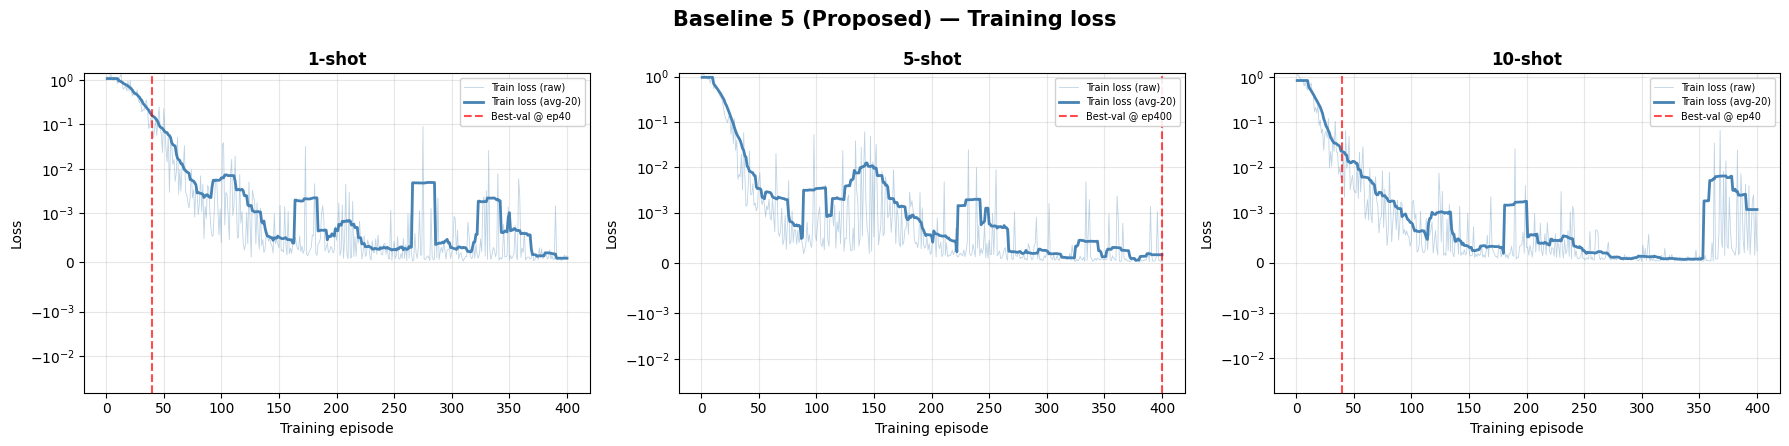

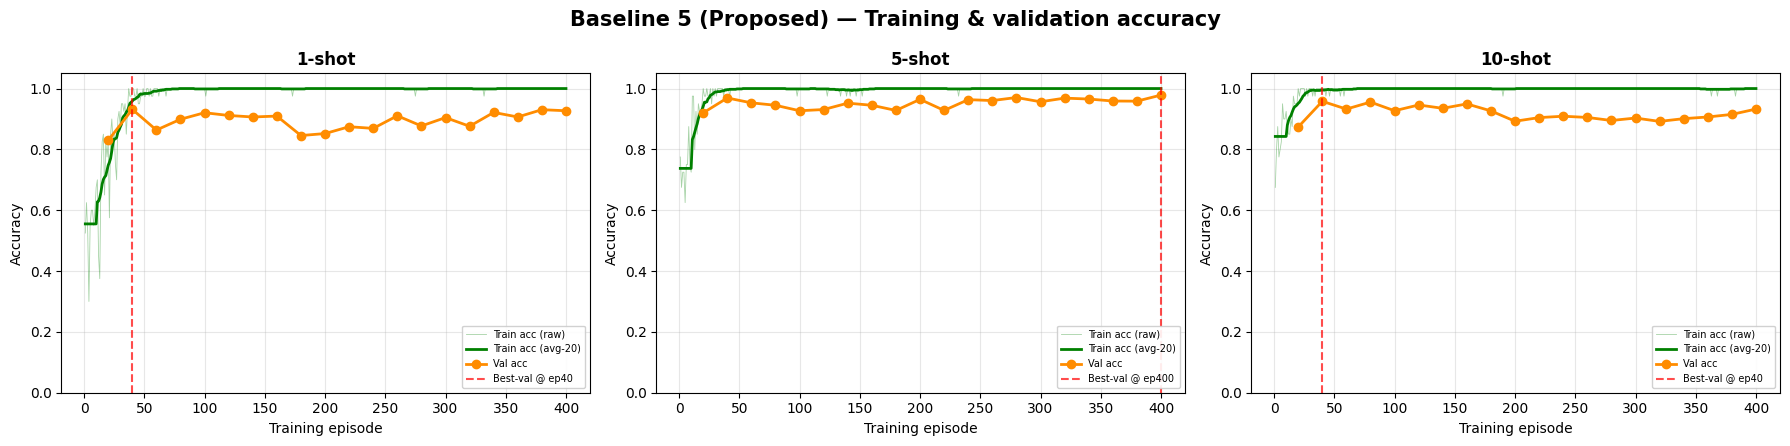

In [5]:
plot_training_loss_and_accuracy(results, baseline_name='Baseline 5 (Proposed)')


## 6. Confusion matrices

Two views per shot count:
- **Episodic (top, blue):** aggregated over evaluation episodes (standard few-shot reporting).
- **Full-test (bottom, green):** every test image classified once, repeated over 30 random support draws from train. This is the most honest per-class view for the small test set.


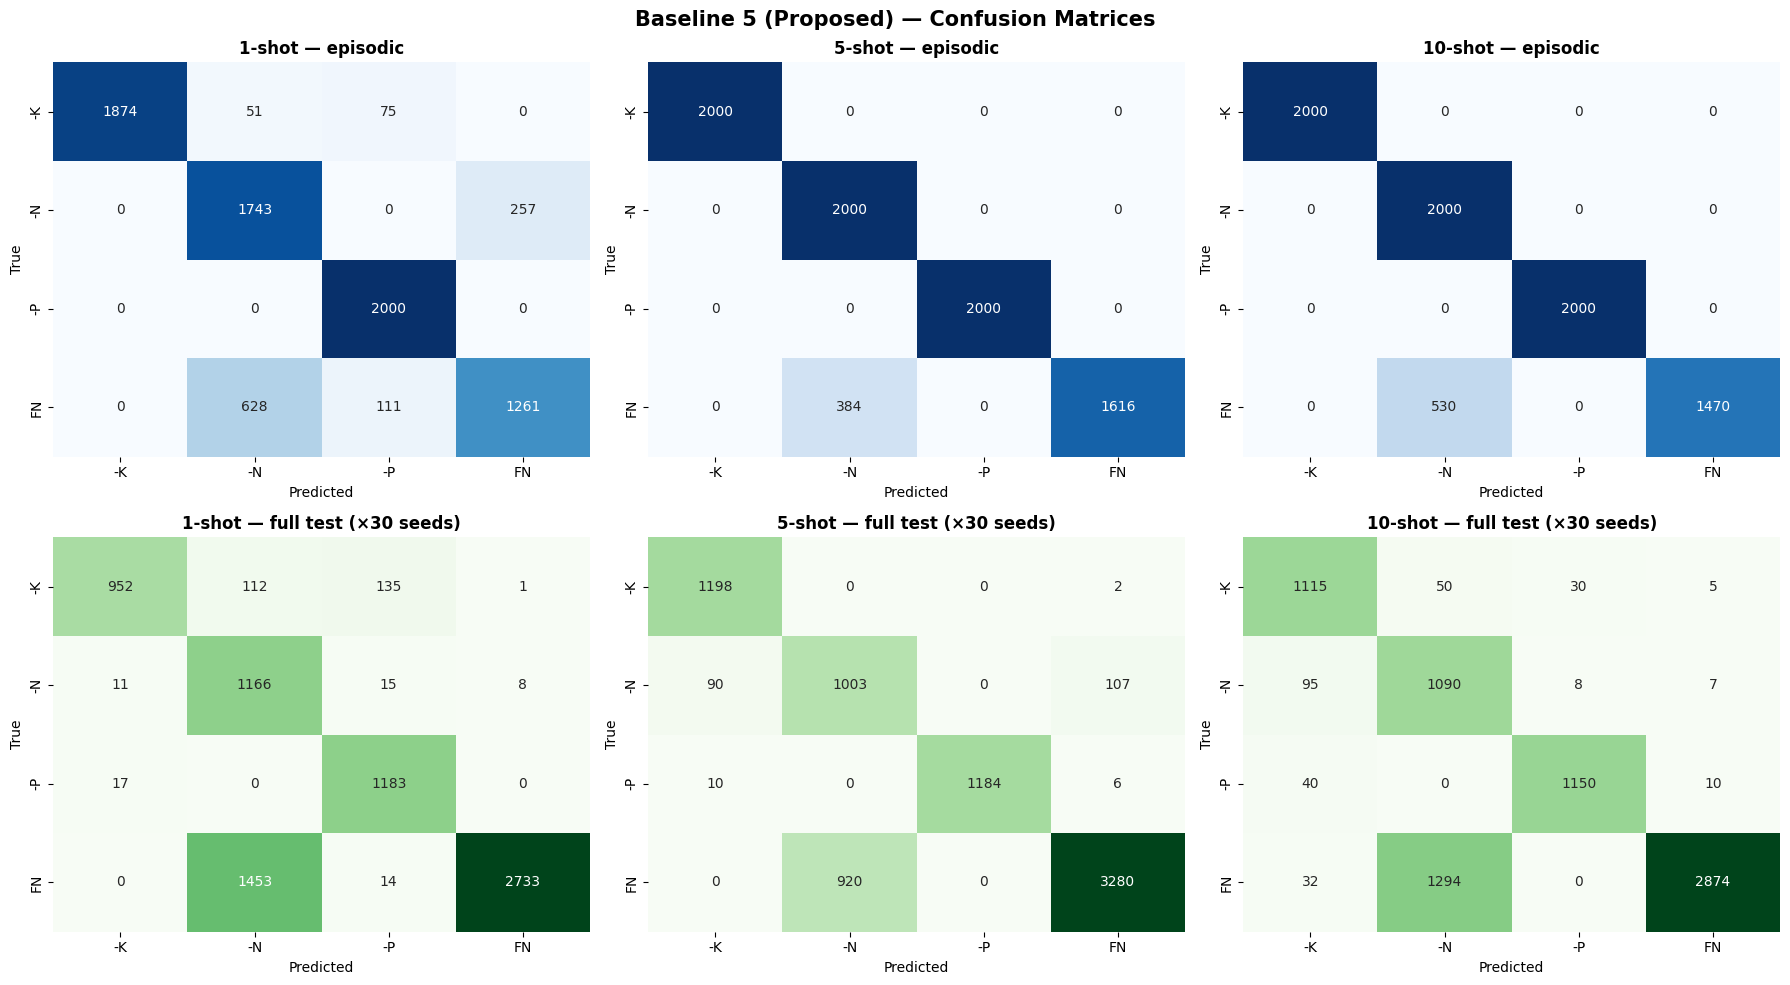

In [6]:
plot_confusion_matrices(results, baseline_name='Baseline 5 (Proposed)')


## 7. Combined view — training trace + test episodic stability

Three-row panel for each shot count:
- **Top:** training loss (raw + smoothed) and best-val marker.
- **Middle:** training accuracy + validation accuracy (no twin y-axis).
- **Bottom:** per-episode accuracy on the test set during episodic evaluation, with mean ± 1σ.


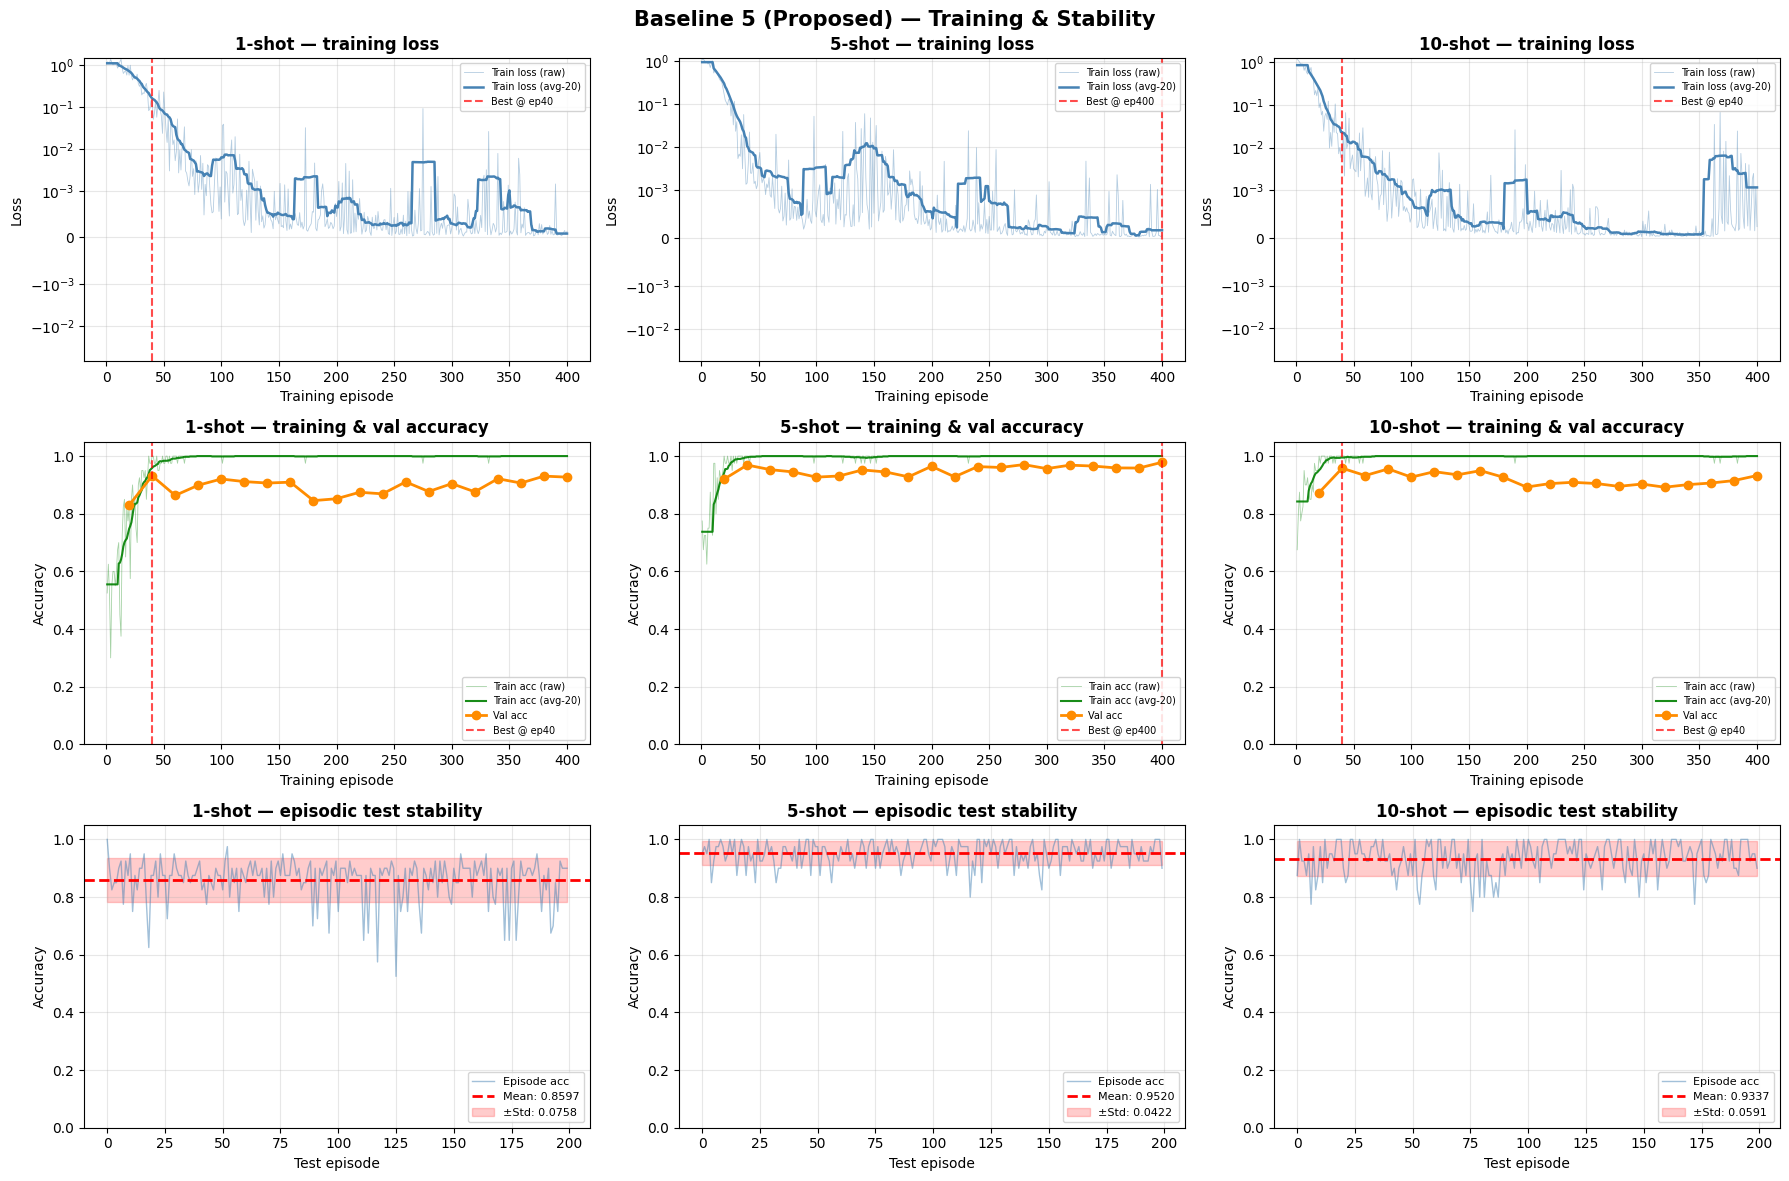

In [7]:
plot_training_curves(results, baseline_name='Baseline 5 (Proposed)')


## 8. Re-evaluate from saved checkpoint (no training)

Once training has been run once, the best-val encoder for each shot count is saved to `checkpoints/`. The cell below shows how to **reload** any of those checkpoints and regenerate test metrics + confusion matrices **without training again** — useful when you just want to re-render the reports, or share a trained model with a collaborator.

It demonstrates reload for 1-shot. To reload another shot count, change `k_shot` and the file path.


Using device: mps
Loaded checkpoint: checkpoints/Baseline_5_(Proposed)_1shot.pt
  metadata: {'baseline': 'Baseline 5 (Proposed)', 'n_support': 1, 'n_way': 4, 'best_val_acc': 0.9315, 'best_episode': 40, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'n_train_episodes_planned': 400}
  Baseline 5 (Proposed) (reloaded 1-shot) — overall
  Shot Accuracy Precision (M) Recall (M) F1 (M)    Episodic μ±σ  95% CI   Best val   Full-test μ±σ
1-shot   0.8598        0.8663     0.8598 0.8571 0.8597 ± 0.0758 ±0.0105 nan @ ep-1 0.7736 ± 0.0299

Per-class metrics on TEST split (deterministic full-test eval):

  Shot Class Precision Recall     F1
1-shot    -K    0.9714 0.7933 0.8734
1-shot    -N    0.4269 0.9717 0.5932
1-shot    -P    0.8782 0.9858 0.9289
1-shot    FN    0.9967 0.6507 0.7874


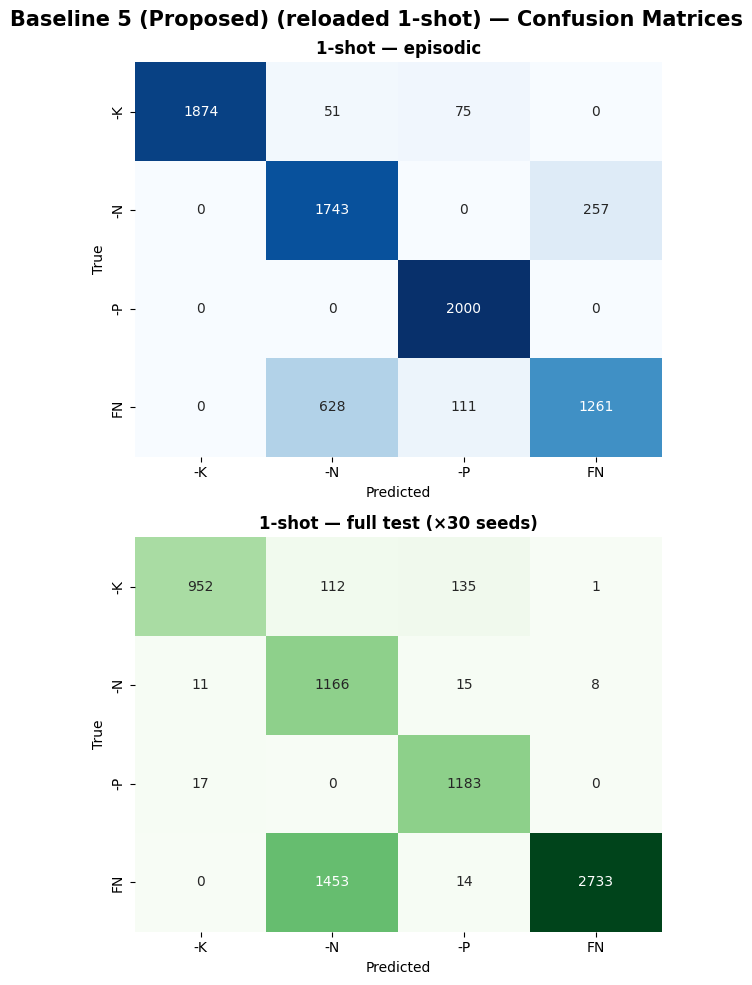

In [8]:
# Replace `k_shot` with 1, 5, or 10 to reload that checkpoint.
k_shot = 1
safe_name = 'Baseline 5 (Proposed)'.replace(' ', '_')
ckpt_path = f'checkpoints/{safe_name}_{k_shot}shot.pt'

reloaded = evaluate_from_checkpoint(
    encoder_factory=lambda: ResNet50MultiScale(freeze_until='layer3'),
    checkpoint_path=ckpt_path,
    data_root='clean_dataset',
    n_way=4,
    k_shot=k_shot,
    n_query=10,
    n_eval_episodes=200,
    n_test_seeds=30,
    seed=42,
)

summarize_results(reloaded, baseline_name=f'Baseline 5 (Proposed) (reloaded {k_shot}-shot)')
plot_confusion_matrices(reloaded, baseline_name=f'Baseline 5 (Proposed) (reloaded {k_shot}-shot)')


## 9. Diagnose: which classes is the model actually confusing?

The macro F1 score hides asymmetric errors. This cell loads a saved checkpoint, runs the deterministic full-test evaluation, and **prints in plain English** which classes are being confused with which others — including the actual confusion matrix in tabular form, the top error pairs, and a per-class breakdown.

Use this to defend your results in the viva. If you see, for example, *'136 FN images were predicted as -N'*, that's a real biological signal — early-stage nitrogen deficiency in lettuce visually resembles healthy leaf variation.


In [9]:
# Diagnose the 1-shot checkpoint — change k_shot to 5 or 10 for the others.
k_shot = 1
safe_name = 'Baseline 5 (Proposed)'.replace(' ', '_')
ckpt_path = f'checkpoints/{safe_name}_{k_shot}shot.pt'

_ = diagnose_checkpoint(
    encoder_factory=lambda: ResNet50MultiScale(freeze_until='layer3'),
    checkpoint_path=ckpt_path,
    data_root='clean_dataset',
    k_shot=k_shot,
    n_seeds=30,
    seed=42,
)


Loaded: checkpoints/Baseline_5_(Proposed)_1shot.pt
  metadata: {'baseline': 'Baseline 5 (Proposed)', 'n_support': 1, 'n_way': 4, 'best_val_acc': 0.9315, 'best_episode': 40, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'n_train_episodes_planned': 400}

Test-Time Augmentation: ENABLED (10 perturbations per image)

Confusion matrix on 30 support draws × full test (7800 total predictions):

 TRUE/PRED |      -K |      -N |      -P |      FN | TOTAL  | RECALL
------------------------------------------------------------------------------
        -K |     952 |     112 |     135 |       1 |  1200  | 0.793
        -N |      11 |    1166 |      15 |       8 |  1200  | 0.972
        -P |      17 |       0 |    1183 |       0 |  1200  | 0.986
        FN |       0 |    1453 |      14 |    2733 |  4200  | 0.651
------------------------------------------------------------------------------
     TOTAL |     980 |    2731 |    1347 |    2742 | 7800
 PRECISION |   0.971 |   0.427 |   0.878 |   0.99

## 10. Upload a new image and predict

Uses the **same Prototypical inference** as evaluation: class prototypes are built from `k_shot` random **training** images per class (RNG matches `full_test_eval` when `support_draw_index` matches that loop index). Your photo is embedded and classified by nearest prototype. **`n_tta=5`** averages several strong augmentations of the query for stabler probabilities.

Requires **`ipywidgets`** (`pip install ipywidgets`). In VS Code / JupyterLab, pick a file with **FileUpload**, then click **Predict**. To use a file path instead, call `predict_image(..., image="path/to.jpg")` in code.


In [10]:
from IPython.display import display
import ipywidgets as widgets

# predict_image is also in the import cell above

k_shot = 1
support_draw_index = 0  # same RNG stream as full_test_eval's first seed (1000+0)
safe_name = 'Baseline 5 (Proposed)'.replace(' ', '_')
ckpt_path = f'checkpoints/{safe_name}_{k_shot}shot.pt'

uploader = widgets.FileUpload(accept='image/*', multiple=False)
go = widgets.Button(description='Predict', button_style='primary')
out = widgets.Output()


def _extract_upload_bytes(u):
    v = u.value
    if not v:
        return None, None
    if isinstance(v, tuple) and len(v) > 0:
        e = v[0]
        if isinstance(e, dict):
            return e.get('content'), e.get('name', 'upload')
        c = getattr(e, 'content', None)
        if c is not None:
            return bytes(c), getattr(e, 'name', 'upload')
    if isinstance(v, dict) and v:
        name, info = next(iter(v.items()))
        return info.get('content'), name
    return None, None


def _on_predict(_):
    with out:
        out.clear_output()
        raw, fname = _extract_upload_bytes(uploader)
        if not raw:
            print('Upload an image, then click Predict.')
            return
        pred = predict_image(
            encoder_factory=lambda: ResNet50MultiScale(freeze_until='layer3'),
            checkpoint_path=ckpt_path,
            image=raw,
            data_root='clean_dataset',
            k_shot=k_shot,
            support_draw_index=support_draw_index,
            n_tta=5,
        )
        print(f'File: {fname}')
        print(
            f"Predicted: {pred['predicted_class']}  "
            f"(class id {pred['class_id']})"
        )
        top = sorted(pred['probabilities'].items(), key=lambda kv: -kv[1])
        print('Probabilities (softmax over negative squared distances):')
        for c, p in top:
            print(f'  {c}: {p:.3f}')


go.on_click(_on_predict)
display(widgets.VBox([
    widgets.HTML(
        '<b>Upload an image</b> — expected classes: -K, -N, -P, FN '
        '(hydroponic lettuce deficiency signs).'
    ),
    uploader,
    go,
    out,
]))
